In [1]:
import numpy as np
from sklearn.decomposition import PCA
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## 1. Loading Data
In this stage, we aggregate raw NetCDF files into a unified high-dimensional array. The dataset is derived from **ECMWF S2S reforecasts**, from which we extract 300 hPa geopotential height ($Z300$).

#### Dataset Dimensions
- **ensemble**: 10 ensemble members  
- **year**: 20 reforecast years (2001–2020)  
- **initialization**: 42 forecast start dates in winter (Oct–Feb)  
- **lead_day**: 47 forecast lead days  
- **latitude**: 61 grid points (Northern Hemisphere)  
- **longitude**: 240 grid points
  
The final data structure is organized as a 6D-tensor with the following dimensions:  
**[Ensemble Member (10), Year (20), Initialization (42), Lead Day (47), Latitude (61), Longitude (240)]**

In [2]:
# --- Domain & Index Definitions ---
n_mb = [f"{i:02}" for i in range(1, 11)]     # Ensemble members 01-10
n_mth_w = ["10", "11", "12", "01", "02"]     # Winter months
yr_rf = np.arange(2001, 2021).astype(str)    # Reforecast period: 2001–2020

# Monthly initialization counts (Oct, Nov, Dec, Jan, Feb)
ini_id = [8, 9, 9, 8, 8]
ini_cum = np.cumsum([0] + ini_id)

t_ = np.arange(0, 47)                        # Lead Time: 0 to 46 forecast days
t_cum = np.arange(0, 148)
dim = [10, 20, 42, 47, 61, 240]              # [Ens, Year, ini, lead, lat, lon]

In [3]:
z_mb = np.zeros(dim)
for i in range(dim[0]):                 # Loop over ensemble members
    for k in range(dim[1]):             # Loop over years
        for m in range(len(n_mth_w)):   # Loop over winter months
            # Load specific NetCDF file for given year/month/ensemble
            file_path = f"/work/DATA/Reforecast/S2S/ECMWF/z/z_{yr_rf[k]}{n_mth_w[m]}_ens{n_mb[i]}.nc"
            with Dataset(file_path) as nc:
                # Data selection: [initialization, all lead days, level 5, lat range, all lon]
                z_mb[i, k, ini_cum[m]:ini_cum[m+1], :, :, :] = nc.variables["gh"][:ini_id[m], :, 5, :61, :]
print(z_mb.shape)

(10, 20, 42, 47, 61, 240)


## 2. Climatology and Anomaly Calculation
To isolate the predictable signals, we remove the Seasonal Climatology (the long-term average) to obtain Anomalies.
- **Climatology:** Computed by averaging across all ensemble members and years.
- **Anomaly:** Represents the deviation of a specific forecast from the expected seasonal mean.

In [4]:
# Average over the first two dimensions (Ensemble and Year)
z_mb_mean = z_mb.mean(axis=0).mean(axis=0)  # Resulting shape: (42, 47, 61, 240)

# --- Anomaly Extraction ---
# Reshape to combine Ensemble and Year into a single 'Sample' dimension (200 samples)
z_mb_reshaped = z_mb.reshape(dim[0] * dim[1], dim[2], dim[3], dim[4], dim[5])

# Subtract climatology to get the anomaly
z_mb_anm = z_mb_reshaped - z_mb_mean

# Restore to 6D structure for subsequent analysis
z_mb_anm_6d = z_mb_anm.reshape(dim[0], dim[1], dim[2], dim[3], dim[4], dim[5])

## 3. Reforecast Data Visualization
To provide an intuitive understanding of the structure of the reforecast data, we randomly select a single initialization instance (the first initialization in October 2001) and examine how the distribution of ensemble members evolves with lead time.
#### Visualization Design
- **Scatter Plot:** Displays the distribution of ensemble members at each lead day, illustrating how the ensemble spread changes as lead time increases.
- **3D Gaussian PDF:** For each lead day, we approximate the ensemble distribution by a Normal distribution $N(\mu,\sigma^2)$ and visualize its corresponding probability density function (PDF) to capture the evolution of uncertainty over time.
- **Observation:** As lead time increases, the spread of ensemble members widens, and the estimated standard deviation grows rapidly. This indicates that forecast uncertainty increases substantially with lead time.

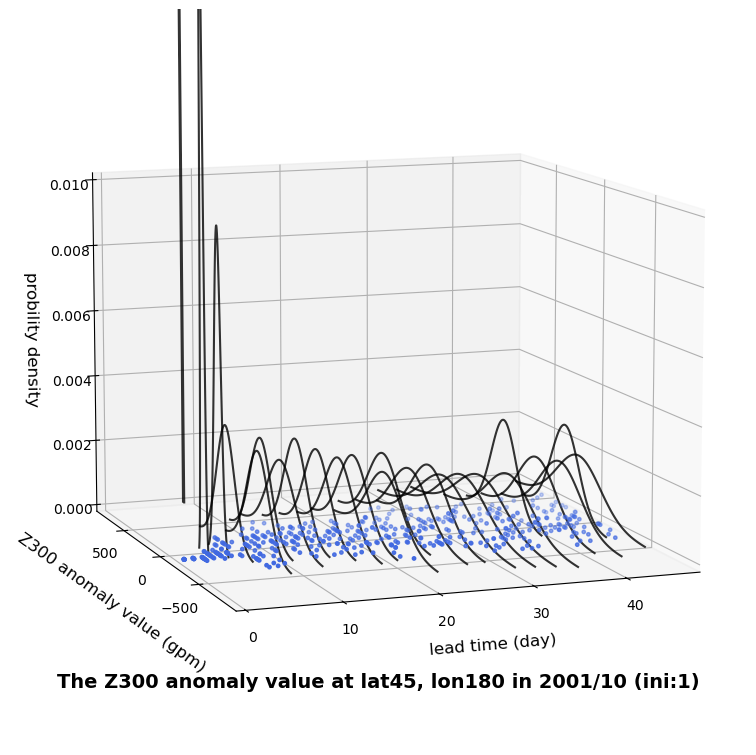

In [5]:
fig1_mean = z_mb_anm_6d[:, 0, 0, :, 30, 120].mean(axis=0)
fig1_std  = z_mb_anm_6d[:, 0, 0, :, 30, 120].std(axis=0)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# Plotting scatter points for all ensemble members
# Location: Lat 45N (index 30), Lon 180E (index 120)
for i in range(0, dim[0]):
    plt.scatter(t_, z_mb_anm_6d[i, 0, 0, :, 30, 120], s=6, zorder=1, c='royalblue')

# Plotting Gaussian PDFs at 2-day intervals to visualize uncertainty growth
for i in range(0, dim[3], 2):
    # Define range for PDF calculation (Mean +/- 3 Standard Deviations)
    y = np.linspace(fig1_mean[i] - 3*fig1_std[i], fig1_mean[i] + 3*fig1_std[i], 100)
    z = norm.pdf(y, fig1_mean[i], fig1_std[i])
    x_vals = np.full_like(y, t_[i])
    ax.plot(x_vals, y, z, color='k', zorder=2, alpha=0.8)
# Axis Configuration
ax.view_init(elev=10, azim=250)
ax.set_xlabel('lead time (day)', labelpad=10, fontsize=12)
ax.set_ylabel('Z300 anomaly value (gpm)', labelpad=10, fontsize=12)
ax.set_zlabel('probility density', labelpad=10, fontsize=12)
ax.set_xlim(0, 47)
ax.set_zlim(0, 0.01)
ax.set_yticks([-500, 0, 500])
fig.suptitle("The Z300 anomaly value at lat45, lon180 in 2001/10 (ini:1)", y=0.11, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Dimensionality Reduction for Predictability Analysis (PCA)
In this stage, we reduce the high-dimensional reforecast data using Principal Component Analysis (PCA) to facilitate predictability analysis.

Given the dataset structure, the temporal dimension is extremely large 
$(10\times20\times42\times47=394,800)$, while the spatial dimension is $(61\times240=14,640)$. 
Direct analysis in the original space is therefore computationally inefficient and difficult to interpret, motivating the use of PCA for dimensionality reduction.

#### Analysis Workflow
1. **Latitude Weighting:** Multiply the data by $\sqrt{\cos\phi}$ to account for spatial area differences, where $\phi$ is latitude.
2. **PCA Implementation:** Apply PCA to the weighted anomalies to extract
   - **EOFs (Empirical Orthogonal Functions)**: spatial patterns
   - **PCs (Principal Components)**: corresponding temporal coefficients
3. **Normalization & Variance Estimation:** The PCs are standardized to unit variance, and their variance is then evaluated as a function of lead time $\tau$.
   - First, variance is computed across ensemble members
   - Then, it is averaged over all years and initialization times to obtain $\sigma_\tau^2$
   - The asymptotic variance $\sigma_\infty^2$ is estimated by averaging over the final 7 lead days, and serves as an empirical upper bound.
5. **Visualization:** Examine how the PCs evolve with lead time.
#### Observation
- Each PC exhibits variance growth consistent with the original $Z300$ field.
- The shaded area between $\sigma_\tau^2$ and $\sigma_\infty^2$ provides a measure of predictability:
a larger area indicates a slower approach to saturation and hence a longer predictable time scale.
- More formally, for each $PC_j$, predictability can be quantified as
  $$\text{Predictability}_j\sim\sum_{\tau=0}^{46}\frac{\sigma_{\tau,j}^2-\sigma_{\infty,j}^2}{\sigma_{\infty,j}^2}$$

In [6]:
# --- 1. Latitude Weighting ---
# Applying area-weighting to account for the convergence of meridians toward the poles
lat_ = np.linspace(90, 0, 61)
wgt_lat = np.sqrt(np.cos(np.deg2rad(lat_)))  # Weight vector (61,)
wgt_lat_mb = np.broadcast_to(wgt_lat.reshape(1, dim[4], 1), 
                             (dim[0]*dim[1]*dim[2]*dim[3], dim[4], dim[5]))

# Weighting the 3D anomaly array
z_mb_anm_3d = z_mb_anm.reshape(dim[0]*dim[1]*dim[2]*dim[3], dim[4], dim[5])
z_mb_anm_3d_wgt = z_mb_anm_3d * wgt_lat_mb

# Reshaping to 2D matrix for PCA input: (Samples x Features)
# Temporal dimension: 394,800 (10 members * 20 years * 42 inits * 47 leads)
# Spatial dimension: 14,640 (61 lat * 240 lon)
z_mb_anm_2d_wgt = z_mb_anm_3d_wgt.reshape(dim[0]*dim[1]*dim[2]*dim[3], dim[4]*dim[5])

In [7]:
# --- 2. PCA Implementation ---
nPC = 10
pca1 = PCA(n_components=nPC, random_state=67)

# Transform data into Principal Components (PCs) and extract EOFs
pcs = pca1.fit_transform(z_mb_anm_2d_wgt)
EOFs = pca1.components_.T

In [8]:
# --- 3. Normalization and Variance Estimation ---
# Normalize PCs to unit variance to evaluate relative predictability
PCs_norm = (pcs - pcs.mean(axis=0)) / pcs.std(axis=0, ddof=1)

# Reshape and calculate variance to observe evolution over lead time (tau)
PCs_norm_5d = PCs_norm.reshape(dim[0], dim[1], dim[2], dim[3], nPC)
PCs_norm_var = PCs_norm_5d.var(axis=0, ddof=1)  # Variance over ensemble members
PCs_norm_var_3d = PCs_norm_var.reshape(dim[1]*dim[2], dim[3], nPC)

# Average variance across years and initializations
PCs_norm_avg_var = PCs_norm_var_3d.mean(axis=0)

# Saturated variance (at long lead times)
PCs_norm_avg_var_max = PCs_norm_avg_var[-7:, :].mean(axis=0)

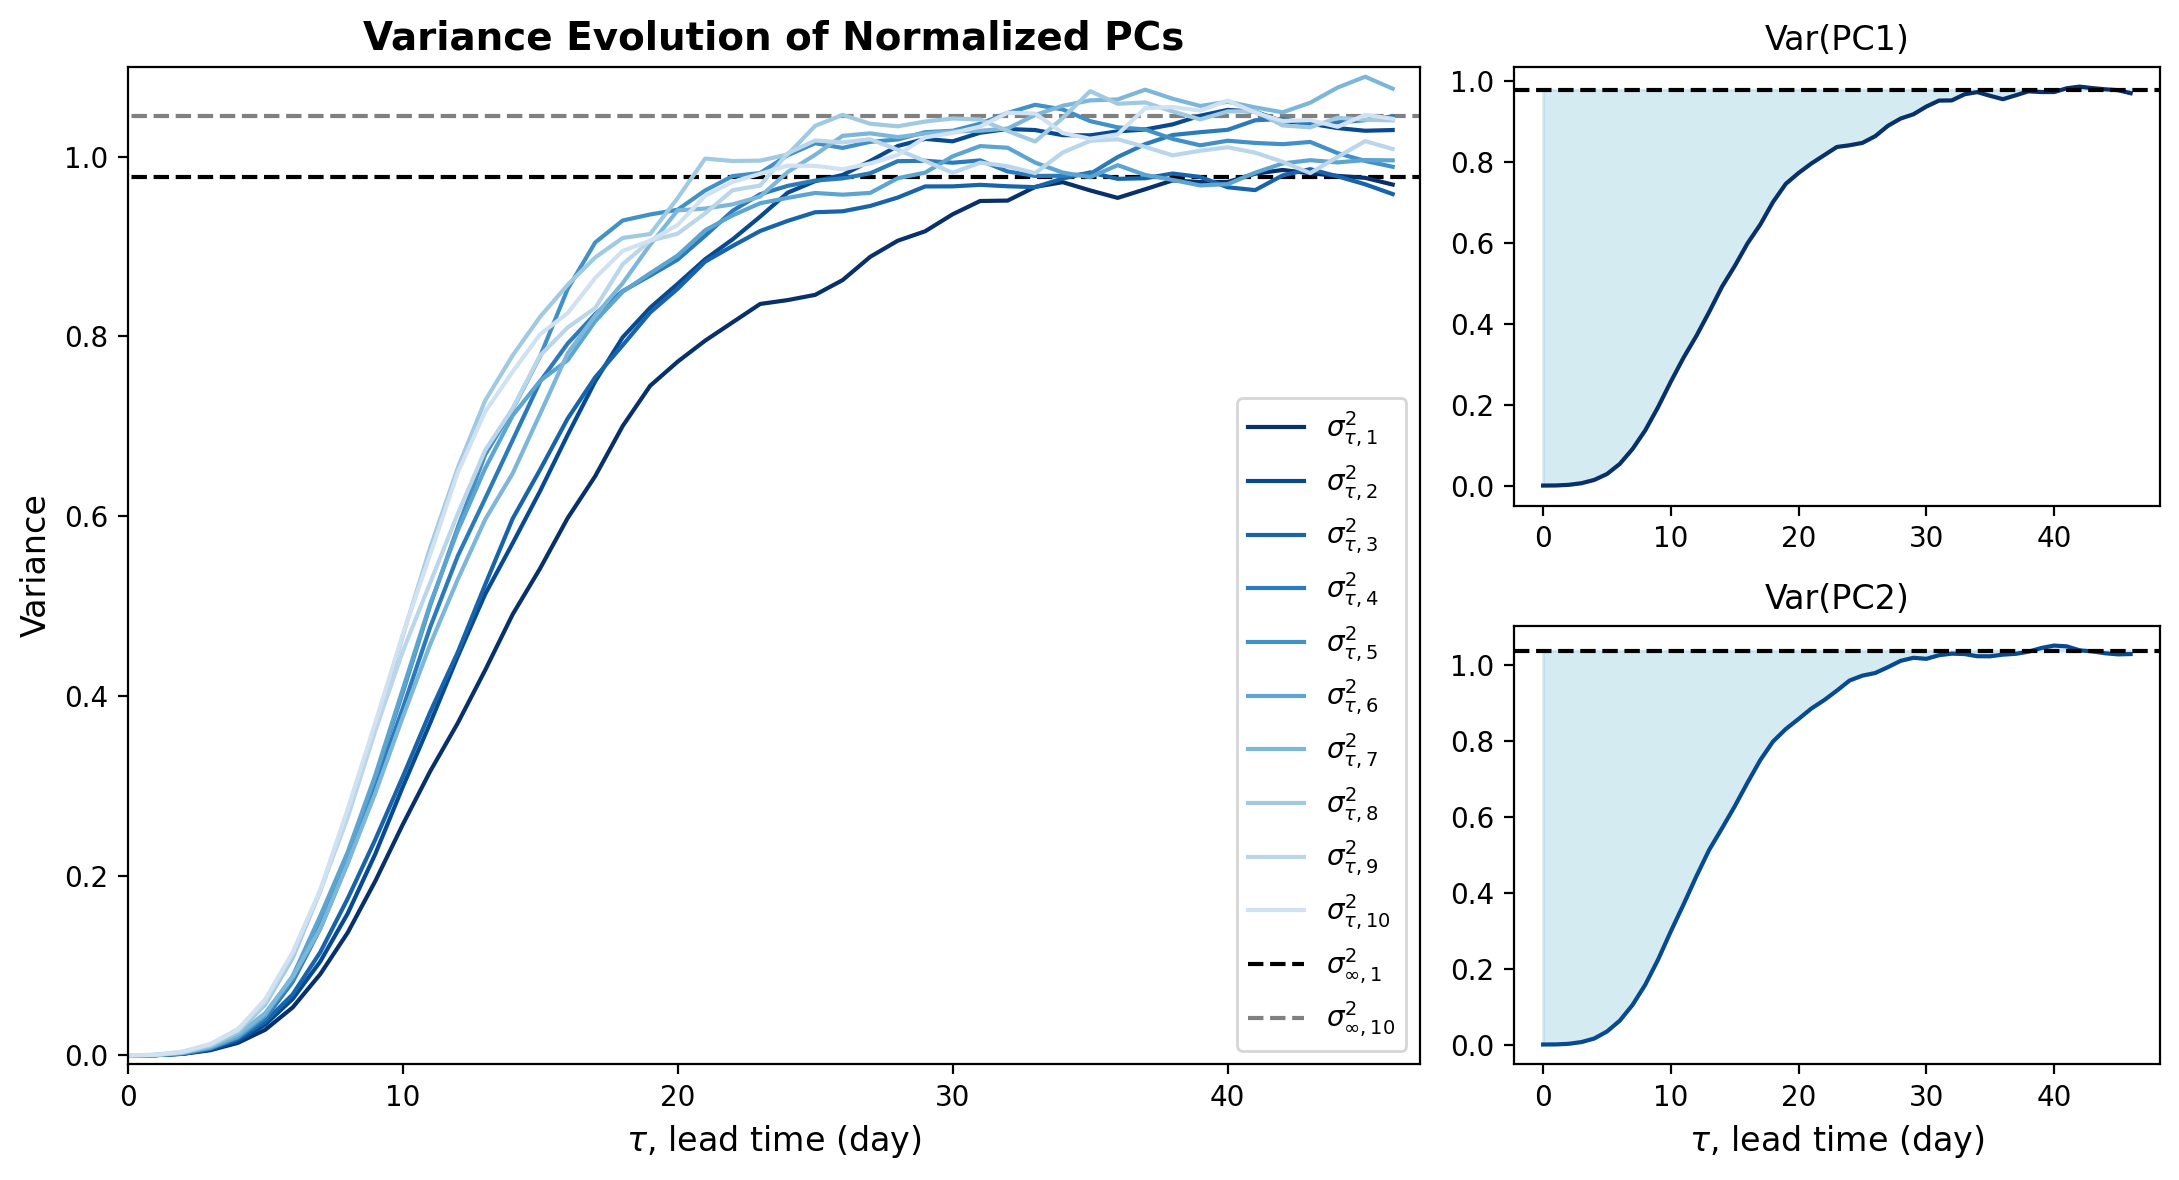

In [9]:
# --- 4. Visualization of PC Variance ---
BLUES = plt.cm.Blues(np.concatenate((np.array([1, 0.9]), np.linspace(0.8, 0.2, 8))))
fig = plt.figure(figsize=(11, 6), dpi=200)
gs = GridSpec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1])

# Main Plot: All 10 PCs
ax1 = fig.add_subplot(gs[:, 0])
for j in range(nPC):
    ax1.plot(t_, PCs_norm_avg_var[:, j], label=f"$\\sigma^2_{{\\tau,{j+1}}}$", c=BLUES[j], zorder=1)

# Baseline: Saturated variance for PC1 and PC10
ax1.axhline(y=PCs_norm_avg_var_max[0], xmin=-1, xmax=47, c='k', zorder=0, 
            linestyle="--", label=r'$\sigma^2_{\infty,1}$')
ax1.axhline(y=PCs_norm_avg_var_max[-1], xmin=-1, xmax=47, c='gray', zorder=0, 
            linestyle="--", label=r'$\sigma^2_{\infty,10}$')

ax1.legend(loc="lower right")
ax1.set(xlim=(0, 47), ylim=(-0.01, 1.1))
ax1.set_xlabel(r"$\tau$, lead time (day)", fontsize=12)
ax1.set_ylabel("Variance", fontsize=12)
ax1.set_title("Variance Evolution of Normalized PCs", fontsize=14, fontweight='bold')

# Subplots for PC1 and PC2 detail
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_, PCs_norm_avg_var[:, 0], label="PC1", c=BLUES[0])
ax2.axhline(y=PCs_norm_avg_var_max[0], c='k', linestyle="--")
ax2.fill_between(t_, PCs_norm_avg_var[:, 0], PCs_norm_avg_var_max[0], color="lightblue", alpha=0.5)
ax2.set_title("Var(PC1)", fontsize=12)

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_, PCs_norm_avg_var[:, 1], label="PC2", c=BLUES[1])
ax3.axhline(y=PCs_norm_avg_var_max[1], c='k', linestyle="--")
ax3.fill_between(t_, PCs_norm_avg_var[:, 1], PCs_norm_avg_var_max[1], color="lightblue", alpha=0.5)
ax3.set_title("Var(PC2)", fontsize=12)
ax3.set_xlabel(r"$\tau$, lead time (day)", fontsize=12)

plt.tight_layout()
plt.show()

## 5. Identifying the Most Predictable Modes
In this final analytical stage, we aim to identify the modes that maximize predictability by finding linear combinations of PCs that retain the forecast signal for the longest time.  
We use linear combinations rather than individual PCs to preserve as much of the original data's explained variance as possible.
#### Analysi Workflow
1. **Calculating Covariance Matrices ($\Sigma_\tau$ & $\Sigma_\infty$):**
   - Compute the covariance matrix of the normalized PCs at each lead time $\tau$, $\Sigma_\tau$
   - Estimate the asymptotic covariance $\Sigma_\infty$ from the final 7 lead days as the long-term limit.
2. **Solving for Optimal Predictability:**
   - Define the predictability operator as
     $$A=\sum_{\tau=0}^{46}\frac{\Sigma_\tau-\Sigma_\infty}{\Sigma_\infty}$$
   - Perform **eigenvalue decomposition** of $A$. The principal eigenvector $e_1$ corresponds to the linear combination of PCs that maximizes the integrated predictability (largest area under $\sigma_\tau^2$ and $\sigma_\infty^2$), while retaining substantial explained variance.
3. **Projection and Visualization:**
   - Project the optimal weighting vector back into the spatial domain to obtain the **Average Predictable Time Modes (APTM)**.
   - Visualize these modes to interpret the spatial patterns associated with the most predictable components.
#### Observation
APTM1 exhibits the PNA (Pacific–North America) teleconnection pattern. Since the PNA is a free-wave 
solution, its period is determined by the forcing period. While a frequency analysis of ATPM1 could further reveal the mechanisms driving PNA excitation, this analysis is not included here.

In [10]:
# --- 1. Calculating Covariance Matrices (Sigma_tau & Sigma_inf) ---
Sigma_tau = np.zeros((dim[3], nPC, nPC))
X_cov = np.zeros((dim[1], dim[2], dim[3], nPC, nPC))

for ld in range(dim[3]):
    for yr in range(dim[1]):
        for ini in range(dim[2]):
            X = PCs_norm_5d[:, yr, ini, ld, :]
            X_cen = X - X.mean(axis=0)
            X_cov[yr, ini, ld, :, :] = np.dot(X_cen.T, X_cen) / (X.shape[0] - 1)
    Sigma_tau[ld, :, :] = X_cov[:, :, ld, :, :].mean(axis=0).mean(axis=0)

# Define saturated variance using the last 7 days of the forecast
Sigma_inf = Sigma_tau[-7:, :, :].mean(axis=0)

In [11]:
# --- 2. Solving for Optimal Weighting Vectors ---
A = np.zeros((nPC, nPC))
for ld in range(dim[3]):
    A += 2 * np.dot(np.linalg.inv(Sigma_inf), Sigma_inf - Sigma_tau[ld, :, :])

# Eigen-decomposition to find the most predictable components
egvl, egvt = np.linalg.eig(A)
sort_id = np.argsort(egvl)[::-1]
egvl_sort, egvt_sort = egvl[sort_id], egvt[:, sort_id]

# Extract the two leading predictable modes (APTM1 & APTM2)
q, q2 = egvt_sort[:, 0], egvt_sort[:, 1]
p, p2 = np.dot(Sigma_inf, q), np.dot(Sigma_inf, q2)

MP_EOF = np.dot(EOFs, p).reshape(61, 240)
MP2_EOF = np.dot(EOFs, p2).reshape(61, 240)

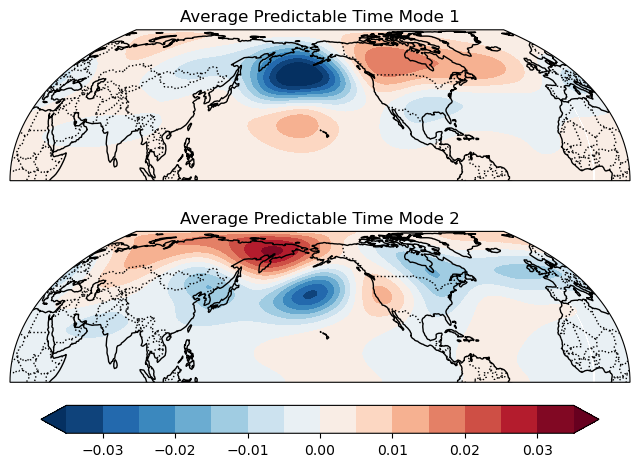

In [12]:
# --- 3. Visualization on Earth Projection ---
lon_ = np.linspace(0, 358.5, 240)
# plot the most predictable mode
fig, axs = plt.subplots(2, 1, figsize=(8, 6), subplot_kw={"projection": ccrs.EqualEarth(central_longitude=200)})

clevs = np.linspace(-0.035, 0.035, 15)
axs[0].add_feature(cfeature.COASTLINE)
axs[0].add_feature(cfeature.BORDERS, linestyle=":")
axs[0].contourf(lon_, lat_, MP_EOF, cmap="RdBu_r", levels=clevs, transform=ccrs.PlateCarree(), extend="both")
axs[0].set_title("Average Predictable Time Mode 1")

axs[1].add_feature(cfeature.COASTLINE)
axs[1].add_feature(cfeature.BORDERS, linestyle=":")
fill = axs[1].contourf(lon_, lat_, MP2_EOF, cmap="RdBu_r", levels=clevs, transform=ccrs.PlateCarree(), extend="both")
axs[1].set_title("Average Predictable Time Mode 2")

fig.colorbar(fill, ax=axs, orientation="horizontal", pad=0.05, shrink=0.9)